## ARTIFICIAL NEURON NETWORK MODEL / FEED FORWARD

Approach:
- Use weighted loss from Pytorch to handle class imbalance internally without creating artifical data
- Use BCEWithLogitsLoss (binary cross-entropy)
- 

In [1]:
#!pip install torch torchvision torchaudio

In [2]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
import os
print(os.getcwd())

c:\Users\joaqu\OneDrive\Documents\Stat Fnd 2


In [4]:
# load clean dataset
df = pd.read_csv("data/cleaned_credit_data_v1.csv")

In [5]:
# list all columns
print(list(df.columns))

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default', 'TOTAL_BILL', 'TOTAL_PAY', 'PAY_RATIO', 'UTILIZATION', 'LIMIT_BAL_LOG', 'AGE_LOG', 'PAY_AVG', 'PAY_MAX', 'PAY_TREND', 'AVG_BILL', 'BILL_STD', 'BILL_TREND', 'AVG_PAY', 'PAY_STD', 'UTIL_X_PAY1', 'RATIO_X_PAY1', 'LIMIT_X_UTIL', 'AGE_X_PAY1']


In [6]:
# split features and target
X = df.drop("default", axis=1)
y = df["default"]

In [7]:
# train/test/split (very important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# standard scale all features (training only to avoid data leakage)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [9]:
# convert to pytorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32)

In [10]:
# handle class imbalance
num_pos = (y_train_tensor == 1).sum()
num_neg = (y_train_tensor == 0).sum()

pos_weight = num_neg / num_pos

In [11]:
# create dataloader (mini-batch training)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# use batch_size 32 to get training stability and good generalization

In [12]:
# build feed forward neural network
class CreditNN(nn.Module):
    def __init__(self, input_dim):
        super(CreditNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # No sigmoid
        )
    
    def forward(self, x):
        return self.model(x)

In [14]:
# loss function and optimizer
model = CreditNN(input_dim=X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # sigmoid + loss combined

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # use learning rate 0.001

In [28]:
train_losses = []
val_losses = []

epochs = 20

for epoch in range(epochs):
    
    # --------------------
    # TRAINING
    # --------------------
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # ✅ average train loss (IMPORTANT FIX)
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    # --------------------
    # VALIDATION
    # --------------------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor).squeeze()
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())


    print(f"Epoch {epoch+1}: "
        f"Train Loss={avg_train_loss:.4f}, "
        f"Val Loss={val_loss.item():.4f}")

Epoch 1: Train Loss=0.7995, Val Loss=0.9245
Epoch 2: Train Loss=0.8009, Val Loss=0.9197
Epoch 3: Train Loss=0.7986, Val Loss=0.9224
Epoch 4: Train Loss=0.7955, Val Loss=0.9282
Epoch 5: Train Loss=0.7905, Val Loss=0.9366
Epoch 6: Train Loss=0.7948, Val Loss=0.9275
Epoch 7: Train Loss=0.7919, Val Loss=0.9295
Epoch 8: Train Loss=0.7875, Val Loss=0.9407
Epoch 9: Train Loss=0.7883, Val Loss=0.9292
Epoch 10: Train Loss=0.7876, Val Loss=0.9328
Epoch 11: Train Loss=0.7817, Val Loss=0.9379
Epoch 12: Train Loss=0.7847, Val Loss=0.9440
Epoch 13: Train Loss=0.7774, Val Loss=0.9471
Epoch 14: Train Loss=0.7811, Val Loss=0.9495
Epoch 15: Train Loss=0.7797, Val Loss=0.9369
Epoch 16: Train Loss=0.7791, Val Loss=0.9515
Epoch 17: Train Loss=0.7753, Val Loss=0.9523
Epoch 18: Train Loss=0.7696, Val Loss=0.9510
Epoch 19: Train Loss=0.7740, Val Loss=0.9705
Epoch 20: Train Loss=0.7785, Val Loss=0.9446


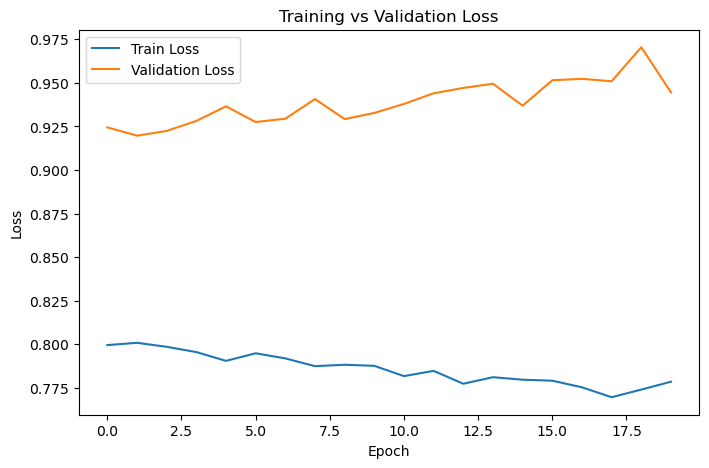

In [29]:
# plot training vs validation loss
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
# evaluate model
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor).squeeze()
    probs = torch.sigmoid(logits)

- turn off gradient tracking. we are not training anymore.
- no need to compute gradients

In [17]:
# threshold tuning
threshold = 0.3
preds = (probs > threshold).float()

we use threshold 0.3 because we want to catch more defaulters 
in an imbalanced dataset and increase recall

In [18]:
# print metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score

# convert tensors to numpy
y_true = y_test_tensor.numpy()
y_pred = preds.numpy()
y_probs = probs.numpy()

print(classification_report(y_true, y_pred))

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_probs))

              precision    recall  f1-score   support

         0.0       0.92      0.41      0.57      4667
         1.0       0.30      0.87      0.44      1326

    accuracy                           0.51      5993
   macro avg       0.61      0.64      0.51      5993
weighted avg       0.78      0.51      0.54      5993

Precision: 0.2962012320328542
Recall: 0.8702865761689291
ROC-AUC: 0.7664770874478584


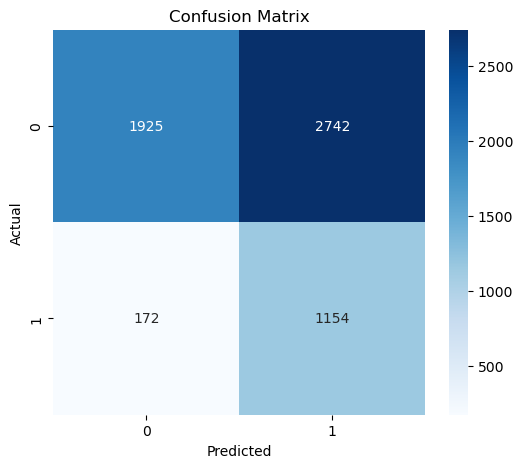

In [19]:
# confusion matrix plot
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## interpretation
- the goal was accomplished: the model is very good at catching defaulters.
- problem: only 30% of predicted defaulters are actually defaulters.
- model flags many non-defaulters as a risk.

Model is optimized to catch defaulters at the cost of many false alarms.

Cause: low threshold and/or class weights

increase threshold to improve precision of the model using F1 optimal threshold tuning

In [ ]:
# find optimal threshold using F1 score
from sklearn.metrics import f1_score

thresholds = np.linspace(0.0, 1.0, 100)

f1_scores = []

for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_true, preds)
    f1_scores.append(f1)

In [23]:
# identify best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1-score:", f1_scores[best_idx])


Best threshold: 0.5252525252525253
Best F1-score: 0.5234323432343234


In [24]:
# final prediction threshold
final_preds = (y_probs > best_threshold).astype(int)

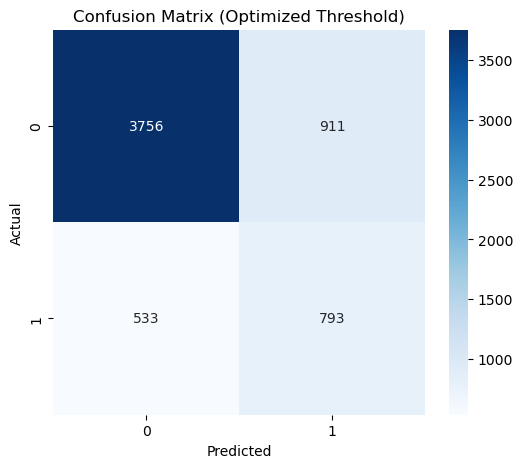

In [25]:
# new classification matrix
y_true = y_test_tensor.numpy()
y_pred = final_preds

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Threshold)")

plt.show()

In [27]:
from sklearn.metrics import accuracy_score

# new classification report and metrics
print(classification_report(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      4667
         1.0       0.47      0.60      0.52      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.70      0.68      5993
weighted avg       0.78      0.76      0.77      5993

Accuracy: 0.7590522275988654
Precision: 0.4653755868544601
Recall: 0.5980392156862745


## interpretation

- When the model says “no default”, it is correct 88% of the time.
- It correctly identifies 80% of all safe customers

- When the model predicts default, it is correct 47% of the time
- It catches 60% of all actual defaulters